# Optimisation du seuil par validation croisée temporelle

Objectif : trouver le seuil optimal (commun aux 4 modèles) qui **minimise la durée totale des alertes** sur le jeu d'entraînement, via une validation croisée temporelle.

In [41]:
import pandas as pd
import numpy as np
import joblib
import sys, os
from importlib import reload
from joblib import Parallel, delayed
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import feature_engineering_function
reload(feature_engineering_function)
from src.feature_engineering_function import build_features

## 1. Chargement et feature engineering (données train)

In [42]:
input_file = '..\\data\\segment_alerts_all_airports_train.csv'
df_train_raw = pd.read_csv(input_file)
print(f'Shape: {df_train_raw.shape}')
df_train_raw.head(3)

Shape: (507071, 13)


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN


In [43]:
df_train, VAR1, TARGET1, IDS1, new_dummies1 = build_features(df_train_raw)
print(f'Shape après features: {df_train.shape}')

✅ Typage & tri
✅ Variables temporelles
✅ Délais passés + futur strict
✅ Comptages rolling
✅ Comptages par type
✅ Taux d'activité
✅ Variables spatiales & azimut
✅ Variables amplitude
✅ Variables alerte
✅ Dynamique orage
✅ Silence & direction
✅ Centre de masse
✅ Cible créée | 507,071 lignes conservées
Shape après features: (507071, 111)


## 2. Chargement des modèles et génération des probabilités

In [44]:
artefacts = joblib.load('../models/xgb_cg10_artefacts.pkl')
model_xgb10 = artefacts['model']
xgb_vars10  = artefacts['vars_to_use']
imputer10   = artefacts['imputer']

artefacts = joblib.load('../models/xgb_cg30_artefacts.pkl')
model_xgb30 = artefacts['model']
xgb_vars30  = artefacts['vars_to_use']
imputer30   = artefacts['imputer']

artefacts = joblib.load('../models/xgb_cg15_artefacts.pkl')
model_xgb15 = artefacts['model']
xgb_vars15  = artefacts['vars_to_use']
imputer15   = artefacts['imputer']

artefacts = joblib.load('../models/xgb_cg15_3km_artefacts.pkl')
model_xgb15_3 = artefacts['model']
xgb_vars15_3  = artefacts['vars_to_use']
imputer15_3   = artefacts['imputer']

In [45]:
VAR = ['min_dist_5min', 'time_since_last_CG20_2', 'log_count_30min', 'amplitude_change',
 'activity_decay', 'time_since_last_intra_cloud2', 'log_cg_count_10min', 'min_dist_1min',
 'cg_20km', 'log_std_amplitude_10min', 'is_cloud_ground', 'log_cg_count_20min',
 'burst_indicator', 'hour', 'storm_direction_change', 'time_since_last_cloud_ground2',
 'std_lat_10min', 'mean_dist_1min', 'dist', 'log_count_5min', 'alert_duration',
 'delta_dist', 'log_ic_count_10min', 'storm_center_distance', 'silence_30min',
 'azimuth_diff', 'max_amplitude_10min', 'std_azimuth_10min', 'storm_spread', 'month',
 'mean_azimuth_1min', 'log_count_20min', 'std_azimuth_1min', 'azimuth',
 'storm_center_velocity', 'log_ic_count_5min', 'max_amplitude_1min', 'storm_velocity',
 'mean_dist_10min', 'storm_center_move', 'mean_azimuth_10min', 'mean_amplitude_1min',
 'cg_ratio', 'rate_trend', 'log_ic_count_20min', 'min_dist_10min', 'azimuth_change',
 'distance_trend', 'mean_dist_5min', 'mean_amplitude_10min', 'std_lon_10min',
 'time_since_last_lightning2', 'log_count_10min', 'log_cg_count_5min',
 'activity_acceleration', 'log_count_1min']

df_train[VAR] = imputer10.fit_transform(df_train[VAR])

df_enc = pd.get_dummies(df_train[xgb_vars10])
df_train['probas_10'] = model_xgb10.predict_proba(df_enc)[:, 1]
df_train['probas_15'] = model_xgb15.predict_proba(df_enc)[:, 1]
df_train['probas_30'] = model_xgb30.predict_proba(df_enc)[:, 1]

df_enc2 = pd.get_dummies(df_train[xgb_vars15_3])
df_train['probas_15_3km'] = 1 - model_xgb15_3.predict_proba(df_enc2)[:, 1]

print('Probabilités calculées.')
df_train[['probas_10', 'probas_15', 'probas_30', 'probas_15_3km']].describe()

Probabilités calculées.


,probas_10,probas_15,probas_30,probas_15_3km
count,5.070710e+05,5.070710e+05,5.070710e+05,5.070710e+05
mean,1.858753e-01,1.455068e-01,1.076727e-01,7.910050e-01
std,3.286633e-01,2.818867e-01,2.649089e-01,3.721953e-01
min,1.772611e-07,3.571805e-07,1.110065e-09,3.576279e-07
25%,3.437449e-05,2.377226e-05,3.032538e-06,8.923067e-01
50%,2.143310e-03,1.277160e-03,1.588642e-04,9.910062e-01
75%,1.735903e-01,9.566457e-02,1.778748e-02,9.982796e-01
max,9.998728e-01,9.992297e-01,9.999342e-01,9.999996e-01


## 3. Définition du système d'alerte paramétrable

In [46]:
def simulate_alert_system(df_airport, SEUIL,
                          ALERT_DURATION=timedelta(minutes=10),
                          DT_INIT=timedelta(minutes=0.5),
                          DT_WAIT=timedelta(minutes=5),
                          GAP_ORAGE=timedelta(hours=1)):
    _ALERT_NS = np.timedelta64(int(ALERT_DURATION.total_seconds()), 's')
    _WAIT_NS  = np.timedelta64(int(DT_WAIT.total_seconds()), 's')
    _INIT_NS  = np.timedelta64(int(DT_INIT.total_seconds()), 's')
    _GAP_S    = GAP_ORAGE.total_seconds()

    df = df_airport.sort_values('date').reset_index(drop=False)
    orig_idx  = df['index'].values
    dates     = pd.to_datetime(df['date']).values.astype('datetime64[ns]')
    p30_v     = df['probas_30'].values
    p15_v     = df['probas_15'].values
    p10_v     = df['probas_10'].values
    p15_3km_v = df['probas_15_3km'].values
    airport   = df['airport'].iloc[0]
    n         = len(df)

    cg20_mask = (~df['icloud'].values.astype(bool)) & (df['dist'].values <= 20)

    last_cg20_idx = np.full(n, -1, dtype=np.int64)
    last = -1
    for k in range(n):
        if cg20_mask[k]:
            last = k
        last_cg20_idx[k] = last

    alerte_arr = np.zeros(n, dtype=np.int8)
    alert_log  = []

    def set_alert_fast(start_i, end_np):
        j_end = min(int(np.searchsorted(dates, end_np, side='right')), n)
        if start_i + 1 < j_end:
            alerte_arr[start_i + 1:j_end] = 1
        return j_end

    def has_lightning_in_window(t_start, t_end, from_i):
        j0 = max(int(np.searchsorted(dates, t_start, side='left')), from_i)
        j1 = int(np.searchsorted(dates, t_end, side='right'))
        return j0 < j1

    def safe_last(next_out, current_i):
        idx = next_out - 1
        if idx <= current_i or idx >= n:
            return None
        return idx

    gaps = np.diff(dates) / np.timedelta64(1, 's')
    ep_bounds = np.where(gaps > _GAP_S)[0] + 1
    ep_starts = np.concatenate([[0], ep_bounds, [n]])

    for ep in range(len(ep_starts) - 1):
        ep_start = int(ep_starts[ep])
        ep_end   = int(ep_starts[ep + 1])

        i              = ep_start
        alert_end      = None
        alert_start_ts = None
        last_in_alert  = None
        next_check     = dates[ep_start] + _INIT_NS

        while i < ep_end:
            t_now = dates[i]

            if cg20_mask[i] and alert_end is None:
                t_end_np       = t_now + _ALERT_NS
                alert_start_ts = pd.Timestamp(t_now)
                next_out       = set_alert_fast(i, t_end_np)
                alert_end      = t_end_np
                last_in_alert  = safe_last(next_out, i)
                alert_log.append({'airport': airport, 'alert_start': pd.Timestamp(t_now),
                                  'alert_end': pd.Timestamp(alert_end), 'type': 'CG20'})
                next_check = alert_end
                i += 1
                continue

            if alert_end is not None and t_now > alert_end:
                if last_in_alert is not None and last_in_alert > ep_start:
                    prolonger = False if last_in_alert >= n else p10_v[last_in_alert] <= SEUIL['p10']
                    new_end = dates[last_in_alert] + _ALERT_NS
                else:
                    prolonger = False
                if prolonger:
                    j_end = set_alert_fast(i - 1, new_end)
                    alert_log.append({'airport': airport, 'alert_start': pd.Timestamp(alert_end),
                                      'alert_end': pd.Timestamp(new_end), 'type': 'prolongation'})
                    alert_end     = new_end
                    last_in_alert = safe_last(j_end, i)
                    next_check    = alert_end
                    continue
                else:
                    alert_end = alert_start_ts = None
                    last_in_alert = None
                    next_check    = t_now
                    continue

            if t_now < next_check:
                i += 1
                continue

            if (p30_v[i] > SEUIL['p30'] and p15_v[i] > SEUIL['p15'] and p10_v[i] > SEUIL['p10']):
                next_check = t_now + _INIT_NS
                i += 1
                continue

            if (p15_v[i] <= SEUIL['p15'] or p15_3km_v[i] <= SEUIL['p15_3'] or p10_v[i] <= SEUIL['p10']):
                if p15_3km_v[i] <= SEUIL['p15_3'] or p10_v[i] <= SEUIL['p10']:
                    t_type         = 'danger_3km' if p15_3km_v[i] <= SEUIL['p15_3'] else 'p10'
                    t_end_np       = t_now + _ALERT_NS
                    alert_start_ts = pd.Timestamp(t_now)
                    next_out       = set_alert_fast(i, t_end_np)
                    alert_end      = t_end_np
                    last_in_alert  = safe_last(next_out, i)
                    alert_log.append({'airport': airport, 'alert_start': alert_start_ts,
                                      'alert_end': pd.Timestamp(t_end_np), 'type': t_type})
                    i += 1
                    next_check = t_end_np
                    continue

            # start_i = min(int(np.searchsorted(dates, t_now + _WAIT_NS, side='left')), ep_end)
            # if not has_lightning_in_window(t_now, t_now + _WAIT_NS, i + 1):
            #     t_end_np       = t_now + _WAIT_NS + _ALERT_NS
            #     alert_start_ts = pd.Timestamp(t_now + _WAIT_NS)
            #     next_out       = set_alert_fast(start_i, t_end_np)
            #     alert_end      = t_end_np
            #     last_in_alert  = safe_last(next_out, i)
            #     alert_log.append({'airport': airport, 'alert_start': alert_start_ts,
            #                       'alert_end': pd.Timestamp(t_end_np), 'type': 'p10'})
            #     #next_check = alert_end
            #     next_check = t_now + _INIT_NS
            #     i += 1
            #     continue
            # else:
            next_check = t_now + _INIT_NS
            i += 1
            continue

    return pd.Series(alerte_arr.astype(int), index=orig_idx), alert_log


def compute_metrics(data_fold, seuil_val):
    """
    Lance la simulation sur un fold et retourne :
      - duree_h   : durée totale d'alerte en heures
      - missed_rate : taux de CG20 non couverts par une alerte active
    Un CG20 est "manqué" si alerte == 0 au moment de l'éclair.
    """
    SEUIL = {'p15_3': seuil_val, 'p30': seuil_val, 'p10': seuil_val, 'p15': seuil_val}
    data_fold = data_fold.reset_index(drop=True)
    groups = list(data_fold.groupby('airport'))

    results = Parallel(n_jobs=-1, backend='loky')(
        delayed(simulate_alert_system)(grp, SEUIL) for _, grp in groups
    )

    all_alerts = pd.Series(0, index=data_fold.index, dtype=int)
    all_logs   = []
    for (_, grp), (result, logs) in zip(groups, results):
        all_alerts.loc[result.index] = result.values
        all_logs.extend(logs)

    # ── Durée totale ─────────────────────────────────────────
    if not all_logs:
        duree_h = 0.0
    else:
        df_a = pd.DataFrame(all_logs)
        df_a['duree_h'] = (df_a['alert_end'] - df_a['alert_start']).dt.total_seconds() / 3600
        duree_h = df_a['duree_h'].sum()

    # ── CG20 manqués ─────────────────────────────────────────
    cg20_mask = (~data_fold['icloud'].astype(bool)) & (data_fold['dist'] <= 20)
    n_cg20 = cg20_mask.sum()
    if n_cg20 == 0:
        missed_rate = 0.0
    else:
        n_missed    = (cg20_mask & (all_alerts == 0)).sum()
        missed_rate = n_missed / n_cg20

    return duree_h, missed_rate

print('Fonctions définies.')

Fonctions définies.


## 4. Validation croisée temporelle

On découpe les données en `K` folds temporels (pas aléatoires, car les données sont des séries temporelles).  
Pour chaque seuil testé, on moyenne la durée totale d'alerte sur les folds de validation.

In [47]:
K_FOLDS = 5
SEUIL_GRID = np.round(np.arange(0.30, 0.96, 0.02), 3)

# Réinitialiser l'index si 'date' est à la fois index et colonne (issu de build_features)
df_train = df_train.reset_index(drop=True)
df_train['date'] = pd.to_datetime(df_train['date'])

# Tri global par date pour le découpage temporel
df_train_sorted = df_train.sort_values('date').reset_index(drop=True)

n_total = len(df_train_sorted)
fold_size = n_total // K_FOLDS

folds = []
for k in range(K_FOLDS):
    start = k * fold_size
    end   = (k + 1) * fold_size if k < K_FOLDS - 1 else n_total
    folds.append(df_train_sorted.iloc[start:end].copy())

print(f'Nombre de folds : {K_FOLDS}')
for k, fold in enumerate(folds):
    print(f'  Fold {k+1}: {len(fold):,} lignes | '
          f'{fold["date"].min().date()} → {fold["date"].max().date()}')

Nombre de folds : 5
  Fold 1: 101,414 lignes | 2016-01-02 → 2016-11-24
  Fold 2: 101,414 lignes | 2016-11-24 → 2018-07-01
  Fold 3: 101,414 lignes | 2018-07-01 → 2019-07-26
  Fold 4: 101,414 lignes | 2019-07-26 → 2021-09-08
  Fold 5: 101,415 lignes | 2021-09-08 → 2022-12-21


In [48]:
cv_results = []

n_seuils = len(SEUIL_GRID)
print(f'Test de {n_seuils} seuils x {K_FOLDS} folds = {n_seuils * K_FOLDS} simulations\n')

for seuil_val in SEUIL_GRID:
    fold_durees  = []
    fold_misseds = []
    for k, fold in enumerate(folds):
        duree_h, missed_rate = compute_metrics(fold, seuil_val)
        fold_durees.append(duree_h)
        fold_misseds.append(missed_rate)
        cv_results.append({'seuil': seuil_val, 'fold': k + 1,
                           'duree_h': duree_h, 'missed_rate': missed_rate})
    print(f'  seuil={seuil_val:.2f}  duree moy={np.mean(fold_durees):>8,.1f} h  '
          f'CG20 manques moy={np.mean(fold_misseds)*100:.1f}%')

df_cv = pd.DataFrame(cv_results)
print('\nValidation croisée terminée.')

Test de 33 seuils x 5 folds = 165 simulations

  seuil=0.30  duree moy=   307.9 h  CG20 manques moy=5.3%
  seuil=0.32  duree moy=   310.7 h  CG20 manques moy=5.1%
  seuil=0.34  duree moy=   313.1 h  CG20 manques moy=4.9%
  seuil=0.36  duree moy=   316.2 h  CG20 manques moy=4.8%
  seuil=0.38  duree moy=   319.2 h  CG20 manques moy=4.7%
  seuil=0.40  duree moy=   322.2 h  CG20 manques moy=4.5%
  seuil=0.42  duree moy=   326.0 h  CG20 manques moy=4.4%
  seuil=0.44  duree moy=   329.8 h  CG20 manques moy=4.3%
  seuil=0.46  duree moy=   333.7 h  CG20 manques moy=4.1%
  seuil=0.48  duree moy=   337.9 h  CG20 manques moy=4.0%
  seuil=0.50  duree moy=   342.9 h  CG20 manques moy=3.9%
  seuil=0.52  duree moy=   347.7 h  CG20 manques moy=3.8%
  seuil=0.54  duree moy=   353.5 h  CG20 manques moy=3.8%
  seuil=0.56  duree moy=   358.8 h  CG20 manques moy=3.6%
  seuil=0.58  duree moy=   364.4 h  CG20 manques moy=3.6%
  seuil=0.60  duree moy=   370.1 h  CG20 manques moy=3.5%
  seuil=0.62  duree moy= 

## 5. Visualisation : durée totale d'alerte vs seuil

Seuil optimal (score combine) : 0.620
  → Duree moy.       : 376.2 h
  → CG20 manques moy.: 3.4%


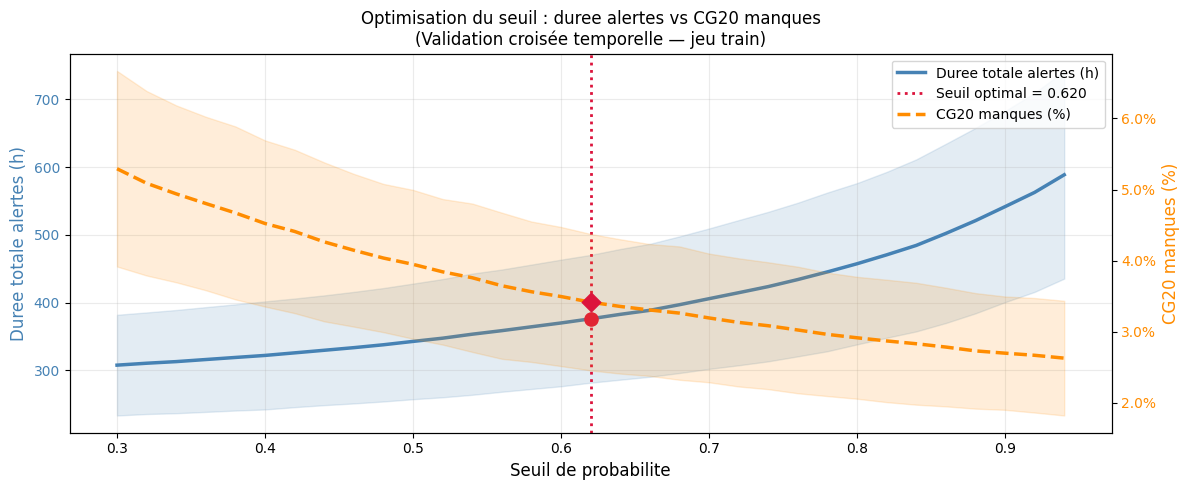

Graphique sauvegarde : threshold_cv_results.png


In [52]:
df_summary = (
    df_cv.groupby('seuil')[['duree_h', 'missed_rate']]
    .agg(['mean', 'std'])
    .reset_index()
)
# Aplatir les colonnes multi-niveaux
df_summary.columns = ['seuil', 'duree_mean', 'duree_std', 'missed_mean', 'missed_std']

# ── Normalisation [0,1] pour superposition ───────────────────
df_summary['duree_norm']  = (df_summary['duree_mean']  - df_summary['duree_mean'].min())  / (df_summary['duree_mean'].max()  - df_summary['duree_mean'].min())
df_summary['missed_norm'] = (df_summary['missed_mean'] - df_summary['missed_mean'].min()) / (df_summary['missed_mean'].max() - df_summary['missed_mean'].min())

# ── Seuil optimal : minimise duree ET CG20 manqués ───────────
# Score combiné = duree normalisée + CG20 manqués normalisés (pondération égale)
df_summary['score'] = df_summary['duree_norm'] + df_summary['missed_norm']
best_idx   = df_summary['score'].idxmin()
best_seuil = df_summary.loc[best_idx, 'seuil']
best_duree = df_summary.loc[best_idx, 'duree_mean']
best_miss  = df_summary.loc[best_idx, 'missed_mean'] * 100

print(f'Seuil optimal (score combine) : {best_seuil:.3f}')
print(f'  → Duree moy.       : {best_duree:,.1f} h')
print(f'  → CG20 manques moy.: {best_miss:.1f}%')

# ════════════════════════════════════════════════════════════════
# GRAPHIQUE : double axe Y
# ════════════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

color_dur  = 'steelblue'
color_miss = 'darkorange'

# Durée totale (axe gauche)
ax1.plot(df_summary['seuil'], df_summary['duree_mean'],
         color=color_dur, linewidth=2.5, label='Duree totale alertes (h)')
ax1.fill_between(df_summary['seuil'],
                 df_summary['duree_mean'] - df_summary['duree_std'],
                 df_summary['duree_mean'] + df_summary['duree_std'],
                 alpha=0.15, color=color_dur)

# CG20 manqués (axe droit)
ax2.plot(df_summary['seuil'], df_summary['missed_mean'] * 100,
         color=color_miss, linewidth=2.5, linestyle='--', label='CG20 manques (%)')
ax2.fill_between(df_summary['seuil'],
                 (df_summary['missed_mean'] - df_summary['missed_std']) * 100,
                 (df_summary['missed_mean'] + df_summary['missed_std']) * 100,
                 alpha=0.15, color=color_miss)

# Ligne seuil optimal
ax1.axvline(best_seuil, color='crimson', linestyle=':', linewidth=2,
            label=f'Seuil optimal = {best_seuil:.3f}')
ax1.scatter([best_seuil], [best_duree], color='crimson', zorder=6, s=90)
ax2.scatter([best_seuil], [best_miss],  color='crimson', zorder=6, s=90, marker='D')

# Mise en forme
ax1.set_xlabel('Seuil de probabilite', fontsize=12)
ax1.set_ylabel('Duree totale alertes (h)', color=color_dur, fontsize=12)
ax2.set_ylabel('CG20 manques (%)',          color=color_miss, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_dur)
ax2.tick_params(axis='y', labelcolor=color_miss)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper right')

ax1.set_title('Optimisation du seuil : duree alertes vs CG20 manques\n(Validation croisée temporelle — jeu train)', fontsize=12)
ax1.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('threshold_cv_results.png', dpi=150)
plt.show()
print(f'Graphique sauvegarde : threshold_cv_results.png')

In [50]:
df_summary[['seuil', 'duree_mean', 'duree_std', 'missed_mean', 'missed_std', 'score']]\
    .style\
    .highlight_min(subset=['duree_mean'], color='lightblue')\
    .highlight_min(subset=['missed_mean'], color='lightgreen')\
    .highlight_min(subset=['score'], color='salmon')\
    .format({'duree_mean': '{:,.1f}', 'duree_std': '{:,.1f}',
             'missed_mean': '{:.3f}', 'missed_std': '{:.3f}',
             'score': '{:.3f}'})

,seuil,duree_mean,duree_std,missed_mean,missed_std,score
0,0.300000,307.9,74.3,0.053,0.014,1.000
1,0.320000,310.7,74.9,0.051,0.013,0.933
2,0.340000,313.1,76.1,0.049,0.012,0.886
3,0.360000,316.2,77.3,0.048,0.012,0.846
4,0.380000,319.2,78.3,0.047,0.012,0.807
5,0.400000,322.2,79.7,0.045,0.012,0.762
6,0.420000,326.0,80.1,0.044,0.012,0.734
7,0.440000,329.8,81.0,0.043,0.011,0.692
8,0.460000,333.7,82.3,0.041,0.011,0.661
9,0.480000,337.9,83.6,0.040,0.010,0.636


## 6. Application du seuil optimal sur le jeu de test

Voir Evaluation_databattle_meteorage.ipynb